In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

DATA_DIR = Path("/Users/nischayaggarwal/Internship 1/data/Processed")
OUT_DIR = Path("/Users/nischayaggarwal/Internship 1/reports")
CHART_DIR = OUT_DIR 
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252

def savefig(name):
    path = CHART_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

In [2]:
nav = pd.read_csv(DATA_DIR / "clean_nav_history.csv")
fund_master = pd.read_csv(DATA_DIR / "clean_fund_master.csv")
benchmark = pd.read_csv(DATA_DIR / "clean_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

fund_cols = [
    "amfi_code", "scheme_name", "fund_house", "category", "sub_category",
    "expense_ratio_pct", "risk_category", "benchmark"
]

nav = nav.merge(fund_master[fund_cols], on="amfi_code", how="left")

print("NAV shape:", nav.shape)
print("Fund master shape:", fund_master.shape)
print("Benchmark shape:", benchmark.shape)
nav.head()

NAV shape: (46000, 10)
Fund master shape: (40, 15)
Benchmark shape: (8050, 3)


,amfi_code,date,nav,scheme_name,fund_house,category,sub_category,expense_ratio_pct,risk_category,benchmark
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,1.55,Moderate,NIFTY 100 TRI
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,1.55,Moderate,NIFTY 100 TRI
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,1.55,Moderate,NIFTY 100 TRI
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,1.55,Moderate,NIFTY 100 TRI
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Large Cap,1.55,Moderate,NIFTY 100 TRI


In [3]:
nav = nav.sort_values(["amfi_code", "date"]).copy()
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

daily_returns_path = OUT_DIR / "daily_returns.csv"
nav.to_csv(daily_returns_path, index=False)

print(f"Saved daily returns: {daily_returns_path}")
nav[["amfi_code", "scheme_name", "date", "nav", "daily_return"]].head(10)

Saved daily returns: /Users/nischayaggarwal/Internship 1/reports/daily_returns.csv


,amfi_code,scheme_name,date,nav,daily_return
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,520.4608,NaN
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971,-0.010306
2,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239,0.012865
3,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880,-0.011377
4,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639,-0.001210
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-10,510.7136,-0.008639
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-11,513.5542,0.005562
7,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-12,512.3195,-0.002404
8,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-13,510.2445,-0.004050
9,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-14,514.3636,0.008073


In [4]:
dist = nav["daily_return"].dropna()

distribution_summary = pd.DataFrame({
    "metric": ["count", "mean", "std", "min", "p1", "p5", "median", "p95", "p99", "max"],
    "value": [
        dist.count(), dist.mean(), dist.std(), dist.min(),
        dist.quantile(0.01), dist.quantile(0.05), dist.median(),
        dist.quantile(0.95), dist.quantile(0.99), dist.max()
    ]
})

distribution_summary.to_csv(OUT_DIR / "daily_return_distribution_summary.csv", index=False)
distribution_summary

,metric,value
0,count,45960.000000
1,mean,0.000631
2,std,0.010290
3,min,-0.058102
4,p1,-0.025982
5,p5,-0.016254
6,median,0.000340
7,p95,0.017842
8,p99,0.027617
9,max,0.064713


Saved: /Users/nischayaggarwal/Internship 1/reports/daily_return_distribution.png


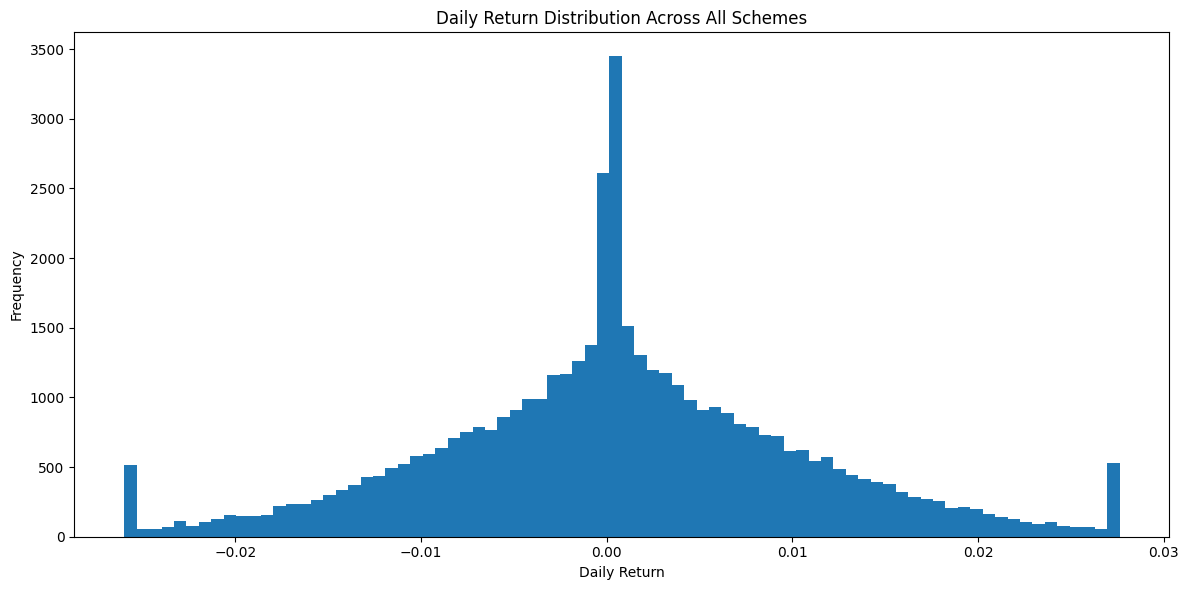

In [5]:
plt.figure(figsize=(12, 6))
plt.hist(dist.clip(dist.quantile(0.01), dist.quantile(0.99)), bins=80)
plt.title("Daily Return Distribution Across All Schemes")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
savefig("daily_return_distribution.png")

In [6]:
def calc_cagr(group, years):
    group = group.sort_values("date").dropna(subset=["nav"])
    if group.empty:
        return np.nan

    end_date = group["date"].max()
    start_cutoff = end_date - pd.DateOffset(years=years)
    eligible = group[group["date"] <= start_cutoff]

    if eligible.empty:
        return np.nan

    start_row = eligible.iloc[-1]
    end_row = group.iloc[-1]

    nav_start = start_row["nav"]
    nav_end = end_row["nav"]
    actual_years = (end_row["date"] - start_row["date"]).days / 365.25

    if nav_start <= 0 or actual_years <= 0:
        return np.nan

    return (nav_end / nav_start) ** (1 / actual_years) - 1


bench = benchmark.sort_values(["index_name", "date"]).copy()
bench["benchmark_return"] = bench.groupby("index_name")["close_value"].pct_change()

nifty100 = bench[bench["index_name"].str.contains("Nifty 100", case=False, na=False)].copy()
if nifty100.empty:
    nifty100 = bench[bench["index_name"].str.contains("100", case=False, na=False)].copy()
if nifty100.empty:
    nifty100 = bench[bench["index_name"] == bench["index_name"].iloc[0]].copy()

nifty50 = bench[bench["index_name"].str.contains("Nifty 50", case=False, na=False)].copy()
if nifty50.empty:
    nifty50 = bench[bench["index_name"].str.contains("50", case=False, na=False)].copy()
if nifty50.empty:
    nifty50 = nifty100.copy()

print("Nifty 100 proxy used:", nifty100["index_name"].iloc[0])
print("Nifty 50 proxy used:", nifty50["index_name"].iloc[0])

Nifty 100 proxy used: NIFTY100
Nifty 50 proxy used: NIFTY50


In [7]:
rows = []

for code, g in nav.groupby("amfi_code"):
    g = g.sort_values("date").copy()
    r = g["daily_return"].dropna()
    latest = g.iloc[-1]

    annual_return = (1 + r).prod() ** (252 / len(r)) - 1 if len(r) > 0 else np.nan
    annual_vol = r.std() * np.sqrt(252) if len(r) > 1 else np.nan

    sharpe = ((r.mean() - RF_DAILY) / r.std()) * np.sqrt(252) if r.std() and r.std() > 0 else np.nan

    downside = r[r < 0]
    downside_std = downside.std()
    sortino = ((r.mean() - RF_DAILY) / downside_std) * np.sqrt(252) if downside_std and downside_std > 0 else np.nan

    # Alpha and Beta against Nifty 100
    merged = g[["date", "daily_return"]].merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) >= 30 and merged["benchmark_return"].std() > 0:
        reg = linregress(merged["benchmark_return"], merged["daily_return"])
        beta = reg.slope
        alpha = reg.intercept * 252
        r_squared = reg.rvalue ** 2
    else:
        beta = alpha = r_squared = np.nan

    # Maximum drawdown
    g["running_max"] = g["nav"].cummax()
    g["drawdown"] = g["nav"] / g["running_max"] - 1

    max_dd = g["drawdown"].min()
    trough_idx = g["drawdown"].idxmin()
    trough_date = g.loc[trough_idx, "date"] if pd.notna(trough_idx) else pd.NaT

    peak_date = pd.NaT
    recovery_date = pd.NaT

    if pd.notna(trough_date):
        before_trough = g[g["date"] <= trough_date]
        peak_nav = before_trough["nav"].max()
        peak_candidates = before_trough[before_trough["nav"] == peak_nav]

        if not peak_candidates.empty:
            peak_date = peak_candidates.iloc[-1]["date"]

            after_trough = g[g["date"] > trough_date]
            recovery = after_trough[after_trough["nav"] >= peak_nav]
            if not recovery.empty:
                recovery_date = recovery.iloc[0]["date"]

    rows.append({
        "amfi_code": code,
        "scheme_name": latest.get("scheme_name"),
        "fund_house": latest.get("fund_house"),
        "category": latest.get("category"),
        "sub_category": latest.get("sub_category"),
        "risk_category": latest.get("risk_category"),
        "expense_ratio_pct": latest.get("expense_ratio_pct"),
        "latest_nav_date": latest["date"],
        "latest_nav": latest["nav"],
        "daily_return_mean": r.mean(),
        "daily_return_std": r.std(),
        "annual_return_pct": annual_return * 100 if pd.notna(annual_return) else np.nan,
        "annual_volatility_pct": annual_vol * 100 if pd.notna(annual_vol) else np.nan,
        "cagr_1yr_pct": calc_cagr(g, 1) * 100 if pd.notna(calc_cagr(g, 1)) else np.nan,
        "cagr_3yr_pct": calc_cagr(g, 3) * 100 if pd.notna(calc_cagr(g, 3)) else np.nan,
        "cagr_5yr_pct": calc_cagr(g, 5) * 100 if pd.notna(calc_cagr(g, 5)) else np.nan,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "alpha_pct": alpha * 100 if pd.notna(alpha) else np.nan,
        "beta": beta,
        "r_squared": r_squared,
        "max_drawdown_pct": max_dd * 100 if pd.notna(max_dd) else np.nan,
        "drawdown_peak_date": peak_date,
        "drawdown_trough_date": trough_date,
        "drawdown_recovery_date": recovery_date,
        "observations": len(r)
    })

performance_metrics = pd.DataFrame(rows).sort_values("sharpe_ratio", ascending=False)

performance_metrics.to_csv(OUT_DIR / "performance_metrics.csv", index=False)
performance_metrics.head()

,amfi_code,scheme_name,fund_house,category,sub_category,risk_category,expense_ratio_pct,latest_nav_date,latest_nav,daily_return_mean,...,sharpe_ratio,sortino_ratio,alpha_pct,beta,r_squared,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date,drawdown_recovery_date,observations
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Large Cap,Moderate,1.46,2026-05-29,230.2708,0.001074,...,1.448291,2.385644,26.983751,0.023684,4.625437e-04,-11.265729,2023-07-11,2023-10-20,2024-02-21,1149
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Flexi Cap,Moderately High,1.45,2026-05-29,163.2397,0.001082,...,1.306744,2.364320,27.330465,-0.022830,3.430543e-04,-12.973968,2022-03-07,2022-04-13,2022-09-22,1149
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,ELSS,High,1.60,2026-05-29,97.7435,0.001124,...,1.234930,2.146914,28.270368,0.018134,1.748889e-04,-16.396743,2023-08-10,2023-10-20,2024-04-10,1149
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Large Cap,Moderate,1.54,2026-05-29,149.3216,0.000917,...,1.208267,2.140267,23.201007,-0.031751,8.869789e-04,-15.012385,2023-08-24,2024-02-05,2025-01-08,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,High,1.36,2026-05-29,473.7640,0.001161,...,1.180101,2.029353,29.263583,0.000549,1.345534e-07,-18.188514,2024-10-24,2025-01-23,2025-03-07,1149


In [8]:
alpha_beta = performance_metrics[
    ["amfi_code", "scheme_name", "fund_house", "alpha_pct", "beta", "r_squared", "observations"]
].sort_values("alpha_pct", ascending=False)

alpha_beta.to_csv(OUT_DIR / "alpha_beta.csv", index=False)
alpha_beta.head(10)

,amfi_code,scheme_name,fund_house,alpha_pct,beta,r_squared,observations
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,30.336965,-0.023196,1.414258e-04,1149
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,30.057878,0.011455,3.532991e-05,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.263583,0.000549,1.345534e-07,1149
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,28.270368,0.018134,1.748889e-04,1149
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,27.330465,-0.022830,3.430543e-04,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,27.195355,0.005104,1.206652e-05,1149
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,26.983751,0.023684,4.625437e-04,1149
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,26.598578,-0.002523,3.357978e-06,1149
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,26.076669,-0.066265,1.936879e-03,1149
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,23.201007,-0.031751,8.869789e-04,1149


In [9]:
score = performance_metrics.copy()

score["return_3yr_rank_score"] = score["cagr_3yr_pct"].rank(pct=True) * 100
score["sharpe_rank_score"] = score["sharpe_ratio"].rank(pct=True) * 100
score["alpha_rank_score"] = score["alpha_pct"].rank(pct=True) * 100

# Lower expense ratio is better
score["expense_rank_score_inverse"] = score["expense_ratio_pct"].rank(ascending=False, pct=True) * 100

# Max drawdown is negative; less negative is better, so higher max_drawdown_pct is better
score["max_dd_rank_score_inverse"] = score["max_drawdown_pct"].rank(pct=True) * 100

score["fund_score_0_100"] = (
    0.30 * score["return_3yr_rank_score"].fillna(0) +
    0.25 * score["sharpe_rank_score"].fillna(0) +
    0.20 * score["alpha_rank_score"].fillna(0) +
    0.15 * score["expense_rank_score_inverse"].fillna(0) +
    0.10 * score["max_dd_rank_score_inverse"].fillna(0)
).round(2)

fund_scorecard = score.sort_values("fund_score_0_100", ascending=False)
fund_scorecard.to_csv(OUT_DIR / "fund_scorecard.csv", index=False)

fund_scorecard[
    ["amfi_code", "scheme_name", "fund_house", "fund_score_0_100",
     "cagr_3yr_pct", "sharpe_ratio", "alpha_pct", "expense_ratio_pct", "max_drawdown_pct"]
].head(10)

,amfi_code,scheme_name,fund_house,fund_score_0_100,cagr_3yr_pct,sharpe_ratio,alpha_pct,expense_ratio_pct,max_drawdown_pct
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,86.25,33.991970,1.448291,26.983751,1.46,-11.265729
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,82.25,31.769243,1.180101,29.263583,1.36,-18.188514
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,82.00,29.575111,1.306744,27.330465,1.45,-12.973968
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,80.75,32.433971,1.093699,27.195355,1.38,-16.217209
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,80.00,32.478927,1.026524,21.194827,0.80,-12.588276
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,77.00,35.102528,0.998231,26.076669,1.38,-20.960884
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,74.81,30.448613,1.208267,23.201007,1.54,-15.012385
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,73.69,29.171358,1.234930,28.270368,1.60,-16.396743
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,68.19,28.960211,1.027213,21.399785,1.60,-11.291596
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,67.38,26.663091,0.945308,30.336965,1.43,-28.706006


Saved: /Users/nischayaggarwal/Internship 1/reports/top10_fund_scorecard.png


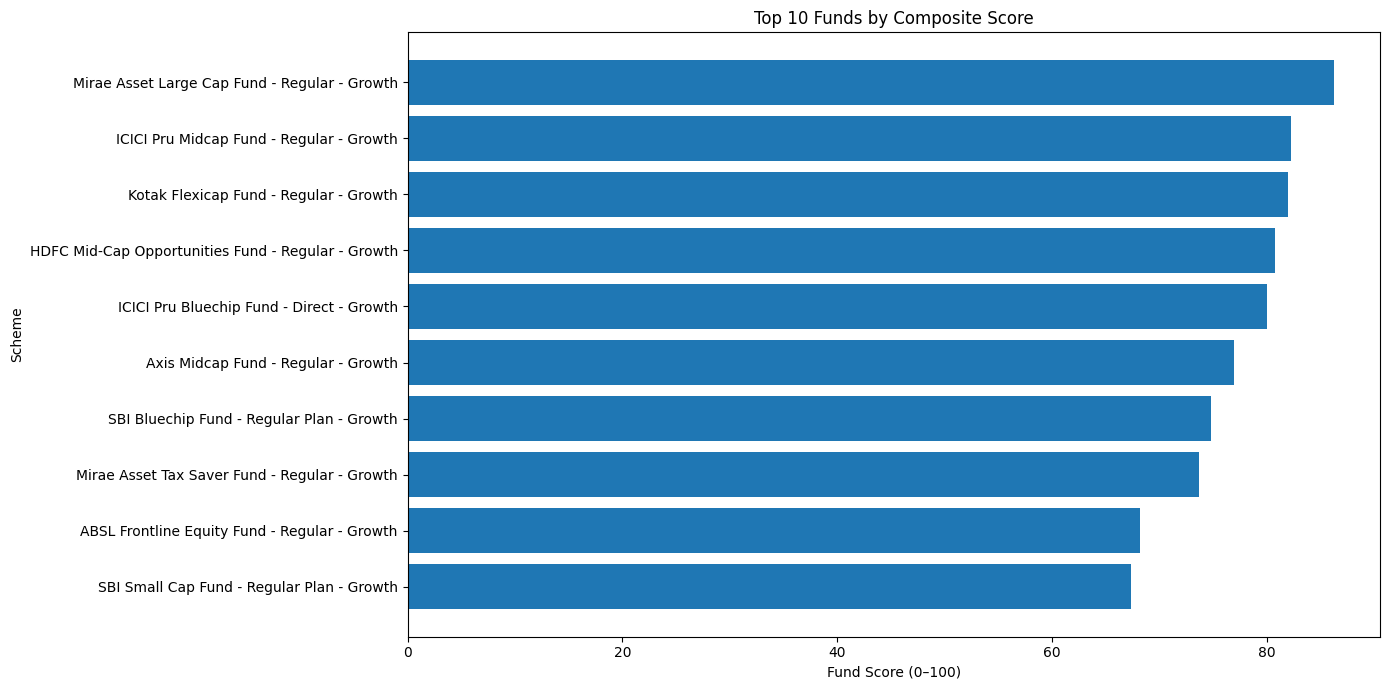

In [10]:
top10 = fund_scorecard.head(10).sort_values("fund_score_0_100")

plt.figure(figsize=(14, 7))
plt.barh(top10["scheme_name"], top10["fund_score_0_100"])
plt.title("Top 10 Funds by Composite Score")
plt.xlabel("Fund Score (0–100)")
plt.ylabel("Scheme")
savefig("top10_fund_scorecard.png")

In [11]:
tracking_rows = []

for code, g in nav.groupby("amfi_code"):
    latest = g.sort_values("date").iloc[-1]

    for bname, bdf in [("Nifty 50", nifty50), ("Nifty 100", nifty100)]:
        merged = g[["date", "daily_return"]].merge(
            bdf[["date", "benchmark_return"]],
            on="date",
            how="inner"
        ).dropna()

        tracking_error = (
            (merged["daily_return"] - merged["benchmark_return"]).std() * np.sqrt(252)
            if not merged.empty else np.nan
        )

        tracking_rows.append({
            "amfi_code": code,
            "scheme_name": latest["scheme_name"],
            "benchmark_index": bname,
            "tracking_error_pct": tracking_error * 100 if pd.notna(tracking_error) else np.nan,
            "matched_observations": len(merged)
        })

tracking_error = pd.DataFrame(tracking_rows)
tracking_error.to_csv(OUT_DIR / "tracking_error.csv", index=False)
tracking_error.head()

,amfi_code,scheme_name,benchmark_index,tracking_error_pct,matched_observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Nifty 50,20.716770,3447
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,Nifty 100,19.928360,1149
2,100025,HDFC Short Term Debt Fund - Regular - Growth,Nifty 50,15.559438,3447
3,100025,HDFC Short Term Debt Fund - Regular - Growth,Nifty 100,13.453514,1149
4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Nifty 50,23.934764,3447


Saved: /Users/nischayaggarwal/Internship 1/reports/benchmark_comparison_top5.png


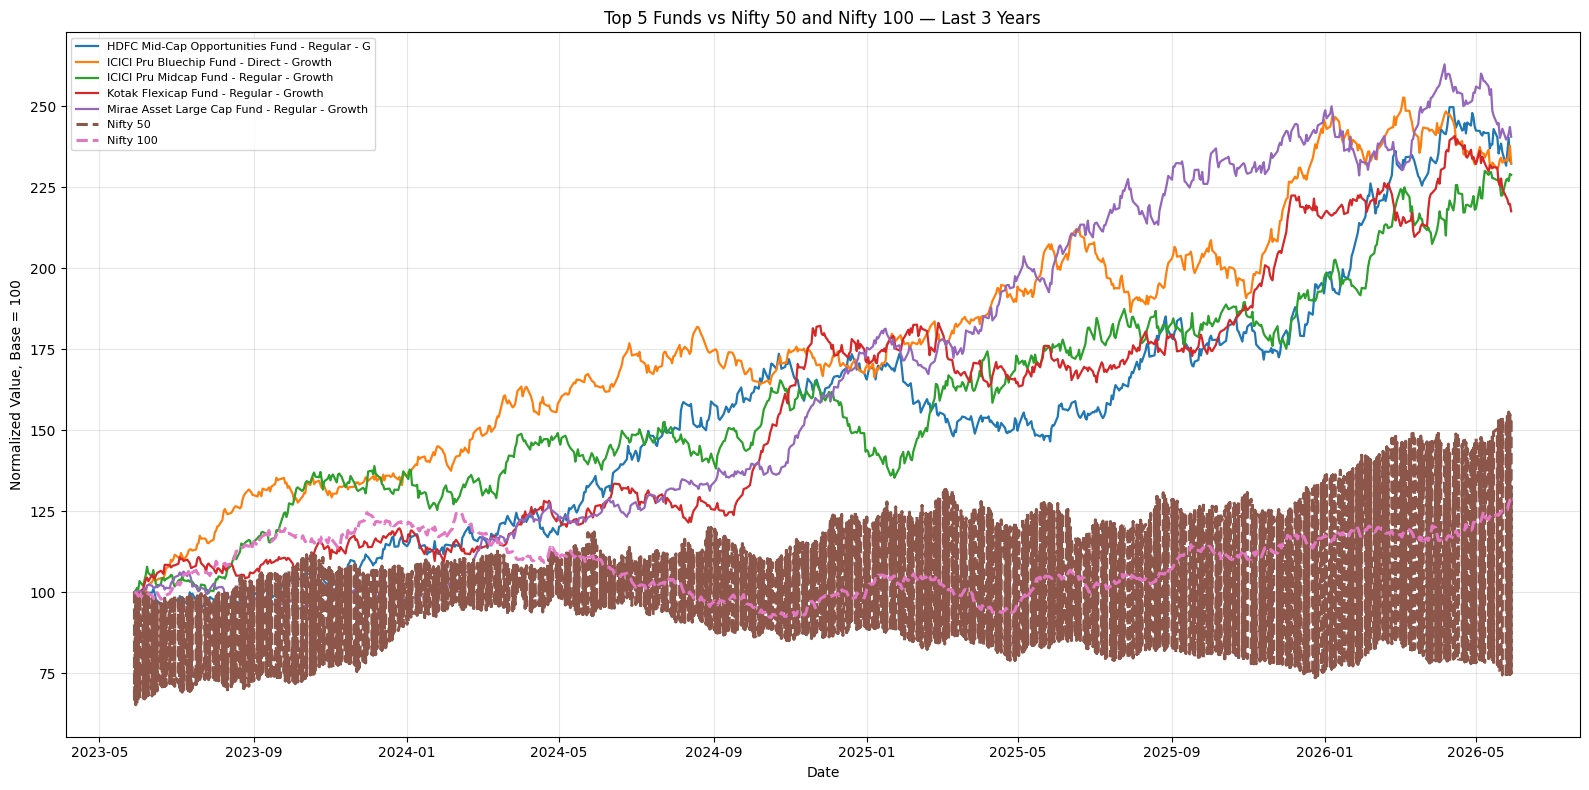

In [12]:
top5_codes = fund_scorecard.head(5)["amfi_code"].tolist()

nav_top5 = nav[nav["amfi_code"].isin(top5_codes)].copy()
end_date = nav_top5["date"].max()
start_date = end_date - pd.DateOffset(years=3)

plt.figure(figsize=(16, 8))

for code, g in nav_top5[nav_top5["date"] >= start_date].sort_values(["amfi_code", "date"]).groupby("amfi_code"):
    name = g["scheme_name"].iloc[0]
    norm = g["nav"] / g["nav"].iloc[0] * 100
    plt.plot(g["date"], norm, linewidth=1.6, label=name[:45])

for label, bdf in [("Nifty 50", nifty50), ("Nifty 100", nifty100)]:
    b = bdf[bdf["date"] >= start_date].sort_values("date").copy()
    if not b.empty:
        norm = b["close_value"] / b["close_value"].iloc[0] * 100
        plt.plot(b["date"], norm, linewidth=2.2, linestyle="--", label=label)

plt.title("Top 5 Funds vs Nifty 50 and Nifty 100 — Last 3 Years")
plt.xlabel("Date")
plt.ylabel("Normalized Value, Base = 100")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

savefig("benchmark_comparison_top5.png")

In [13]:
print("Performance analytics complete.")
print("Saved outputs:")
print(OUT_DIR / "daily_returns.csv")
print(OUT_DIR / "performance_metrics.csv")
print(OUT_DIR / "fund_scorecard.csv")
print(OUT_DIR / "alpha_beta.csv")
print(OUT_DIR / "tracking_error.csv")
print(CHART_DIR / "benchmark_comparison_top5.png")

Performance analytics complete.
Saved outputs:
/Users/nischayaggarwal/Internship 1/reports/daily_returns.csv
/Users/nischayaggarwal/Internship 1/reports/performance_metrics.csv
/Users/nischayaggarwal/Internship 1/reports/fund_scorecard.csv
/Users/nischayaggarwal/Internship 1/reports/alpha_beta.csv
/Users/nischayaggarwal/Internship 1/reports/tracking_error.csv
/Users/nischayaggarwal/Internship 1/reports/benchmark_comparison_top5.png
